# Gedo Weather Forecasts

Forecasts the three monthly weather metrics for the Gedo region with the custom Sybilion client and plots point forecasts with uncertainty bands.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'project').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project.clients.sybilion import (
    SybilionClient,
    build_forecast_body,
    forecast_to_frame,
    monthly_timeseries,
)
from project.domain.regions import GEDO_POLYGON


In [2]:
WEATHER_DIR = PROJECT_ROOT / 'project' / 'data' / 'weather'
FORECAST_DIR = WEATHER_DIR / 'sybilion_gedo'
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

WEATHER_CSV = WEATHER_DIR / 'gedo_monthly_weather_2006_2025.csv'
HORIZON_MONTHS = 12
POLL_SECONDS = 5.0
TIMEOUT_SECONDS = 900.0

metrics = {
    'rainfall_mm_per_day': {
        'label': 'Rainfall (mm/day)',
        'title': 'Gedo monthly rainfall',
        'strictly_positive': False,
        'transform': 'log1p',
    },
    'temperature_avg_c': {
        'label': 'Average temperature (C)',
        'title': 'Gedo monthly average temperature',
        'strictly_positive': False,
        'transform': None,
    },
    'relative_humidity_pct': {
        'label': 'Relative humidity (%)',
        'title': 'Gedo monthly relative humidity',
        'strictly_positive': True,
        'transform': None,
    },
}

weather = pd.read_csv(WEATHER_CSV, parse_dates=['month'])
weather = weather.sort_values('month').reset_index(drop=True)
print(f'Loaded {len(weather)} Gedo weather rows from {WEATHER_CSV}')
weather.tail()


Loaded 240 Gedo weather rows from /home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/weather/gedo_monthly_weather_2006_2025.csv


,region,month,rainfall_mm_per_day,temperature_avg_c,relative_humidity_pct
235,gedo,2025-08-01,0.079862,26.993440,50.092200
236,gedo,2025-09-01,0.070371,28.043840,47.663403
237,gedo,2025-10-01,0.208135,28.820599,49.816660
238,gedo,2025-11-01,0.200050,29.309880,48.108234
239,gedo,2025-12-01,0.101919,29.977015,44.072296


In [3]:
def forecast_metric(metric_name, config, *, force_refresh=False):
    forecast_json_path = FORECAST_DIR / f'{metric_name}_forecast.json'
    forecast_csv_path = FORECAST_DIR / f'{metric_name}_forecast.csv'
    body_path = FORECAST_DIR / f'{metric_name}_request.json'
    job_path = FORECAST_DIR / f'{metric_name}_job.json'

    ts = monthly_timeseries(weather, 'month', metric_name)
    ts_path = FORECAST_DIR / f'{metric_name}_history.csv'
    ts.to_csv(ts_path, index=False)

    model_ts = ts.copy()
    if config.get('transform') == 'log1p':
        model_ts['value'] = np.log1p(model_ts['value'].clip(lower=0))

    if forecast_json_path.exists() and not force_refresh:
        forecast = json.loads(forecast_json_path.read_text(encoding='utf-8'))
        print(f'Loaded cached forecast for {metric_name}: {forecast_json_path}')
    else:
        body = build_forecast_body(
            model_ts,
            title=config['title'],
            description=(
                f'Monthly ERA5-Land {config["label"]} for the Gedo region in Somalia. '
                'The source region polygon is project.domain.regions.GEDO_POLYGON. '
                f'Model transform: {config.get("transform") or "none"}.'
            ),
            keywords=['Somalia', 'Gedo', 'weather', 'ERA5-Land', metric_name],
            horizon=HORIZON_MONTHS,
            frequency='monthly',
            backtest=True,
            recency_factor=0.75,
            strictly_positive=config['strictly_positive'],
        )
        body_path.write_text(json.dumps(body, indent=2), encoding='utf-8')

        client = SybilionClient()
        job, forecast = client.run_forecast(
            body,
            poll_s=POLL_SECONDS,
            timeout_s=TIMEOUT_SECONDS,
            verbose=True,
        )
        job_path.write_text(json.dumps(job.payload, indent=2), encoding='utf-8')
        forecast_json_path.write_text(json.dumps(forecast, indent=2), encoding='utf-8')

    fc = forecast_to_frame(forecast)
    if config.get('transform') == 'log1p':
        value_columns = ['forecast', 'q05', 'q10', 'q25', 'q50', 'q75', 'q90', 'q95']
        fc[value_columns] = np.expm1(fc[value_columns].astype(float)).clip(lower=0)
    fc.insert(0, 'metric', metric_name)
    fc.to_csv(forecast_csv_path, index=False)
    return ts, fc


In [4]:
histories = {}
forecasts = {}

for metric_name, config in metrics.items():
    histories[metric_name], forecasts[metric_name] = forecast_metric(
        metric_name,
        config,
        force_refresh=False,
    )

all_forecasts = pd.concat(forecasts.values(), ignore_index=True)
all_forecasts.to_csv(FORECAST_DIR / 'gedo_weather_sybilion_forecasts.csv', index=False)
all_forecasts


Loaded cached forecast for rainfall_mm_per_day: /home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/weather/sybilion_gedo/rainfall_mm_per_day_forecast.json
Loaded cached forecast for temperature_avg_c: /home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/weather/sybilion_gedo/temperature_avg_c_forecast.json
Loaded cached forecast for relative_humidity_pct: /home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/weather/sybilion_gedo/relative_humidity_pct_forecast.json


,metric,date,forecast,q05,q10,q25,q50,q75,q90,q95
0,rainfall_mm_per_day,2026-01-01,0.241402,0.023297,0.034637,0.038682,0.241402,0.483685,0.489487,0.505992
1,rainfall_mm_per_day,2026-02-01,1.065931,0.401796,0.511297,0.833215,1.065931,1.328187,1.824112,2.044717
2,rainfall_mm_per_day,2026-03-01,0.376784,0.000000,0.052030,0.145572,0.376784,0.654659,0.801783,1.281543
3,rainfall_mm_per_day,2026-04-01,0.549372,0.000000,0.000000,0.202674,0.549372,0.996018,1.928856,1.928856
4,rainfall_mm_per_day,2026-05-01,0.314718,0.000000,0.000000,0.012473,0.314718,0.707189,1.283355,1.283355
5,rainfall_mm_per_day,2026-06-01,0.796828,0.337365,0.563192,0.663256,0.796828,0.941129,1.065384,1.414145
6,rainfall_mm_per_day,2026-07-01,0.685540,0.171119,0.245453,0.445552,0.685540,0.965373,1.281137,1.425925
7,rainfall_mm_per_day,2026-08-01,0.550743,0.067609,0.220310,0.320238,0.550743,0.821492,0.970649,1.252512
8,rainfall_mm_per_day,2026-09-01,0.369680,0.000000,0.078076,0.161809,0.369680,0.614745,0.740160,1.024373
9,rainfall_mm_per_day,2026-10-01,0.482275,0.096682,0.121987,0.208095,0.482275,0.818680,0.958257,1.003443


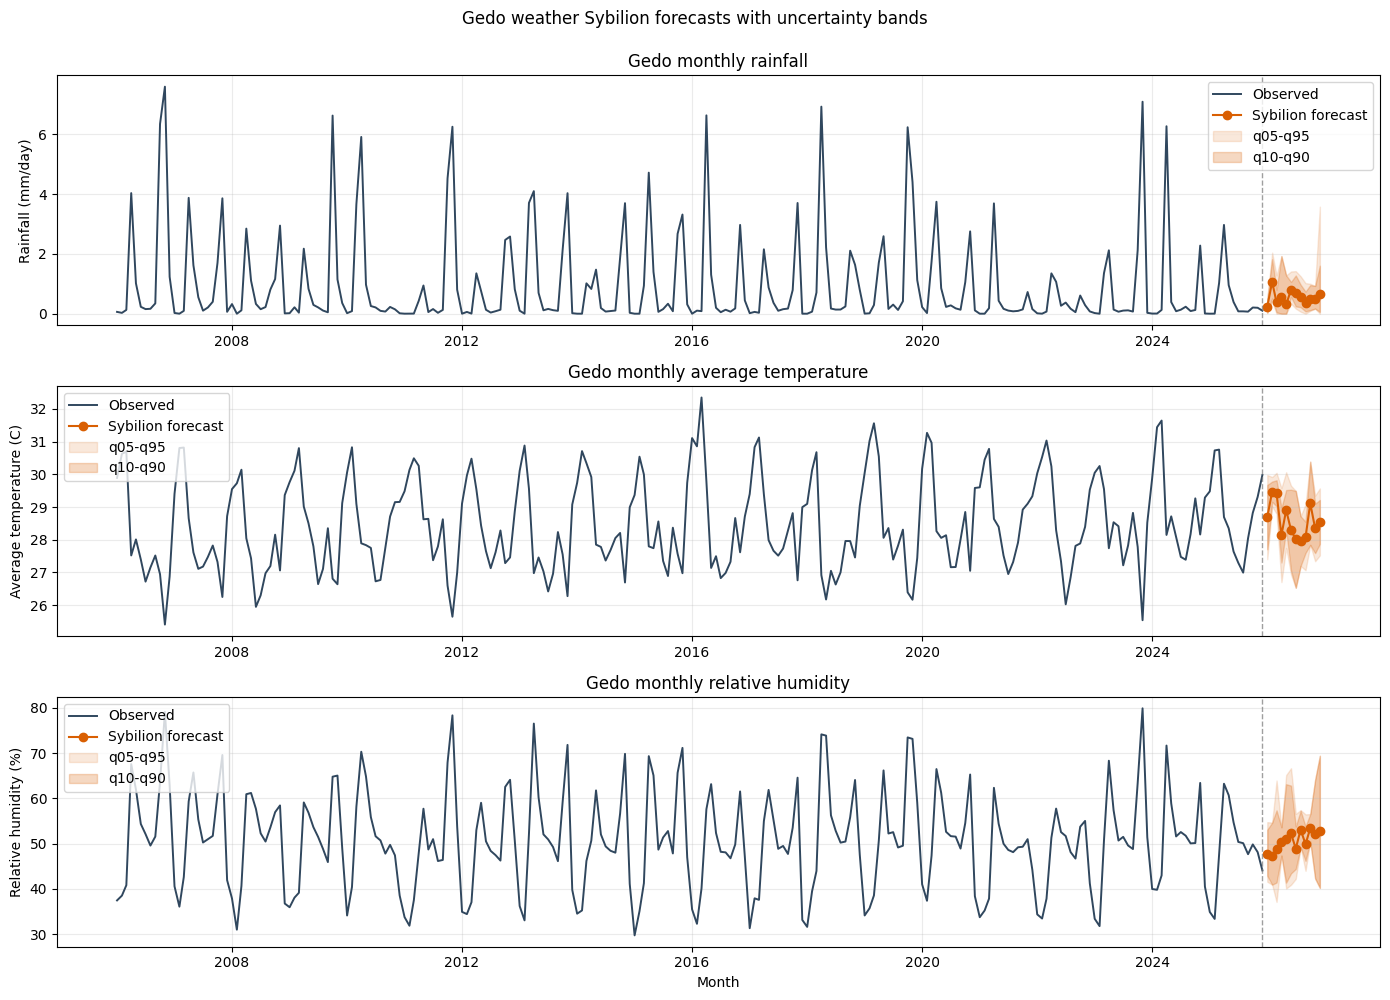

PosixPath('/home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/weather/sybilion_gedo/gedo_weather_sybilion_forecasts.png')

In [5]:
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 10), sharex=False)

for ax, (metric_name, config) in zip(axes, metrics.items()):
    history = histories[metric_name]
    forecast = forecasts[metric_name]

    ax.plot(history['date'], history['value'], color='#30475e', linewidth=1.4, label='Observed')
    ax.plot(forecast['date'], forecast['forecast'], color='#d95f02', marker='o', label='Sybilion forecast')

    if forecast['q05'].notna().any() and forecast['q95'].notna().any():
        ax.fill_between(
            forecast['date'],
            forecast['q05'].astype(float),
            forecast['q95'].astype(float),
            color='#d95f02',
            alpha=0.14,
            label='q05-q95',
        )

    if forecast['q10'].notna().any() and forecast['q90'].notna().any():
        ax.fill_between(
            forecast['date'],
            forecast['q10'].astype(float),
            forecast['q90'].astype(float),
            color='#d95f02',
            alpha=0.24,
            label='q10-q90',
        )

    ax.axvline(history['date'].max(), color='#777777', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_title(config['title'])
    ax.set_ylabel(config['label'])
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Month')
fig.suptitle('Gedo weather Sybilion forecasts with uncertainty bands', y=0.995)
fig.tight_layout()

plot_path = FORECAST_DIR / 'gedo_weather_sybilion_forecasts.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()

plot_path


In [6]:
GEDO_POLYGON


[(42.8903167, 4.3140417),
 (43.0996111, 3.0833333),
 (41.5229722, 1.2651944),
 (40.9924083, 2.7923778),
 (42.0586444, 4.1903472)]